# Notebook 01 — Data Exploration

Goals:
1. Inspect the structure of `axle_data.json` (keys, lengths, dtypes)
2. Visualise representative signal / pulse pairs
3. Analyse class imbalance (fraction of positive samples)
4. Plot the distribution of axle counts per record
5. Check for NaN / inf values

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

JSON_PATH = '../axle_data.json/axle_data.json'

## 1. Peek at raw structure

In [2]:
# Stream-open and read just the first record to inspect keys/shapes
with open(JSON_PATH, 'r') as f:
    raw = json.load(f)

# Unwrap if needed
if isinstance(raw, dict):
    for key in ('records', 'data', 'samples', 'events'):
        if key in raw:
            raw = raw[key]
            print(f'Top-level key used: {key!r}')
            break

print(f'Total records : {len(raw):,}')
print(f'Keys in record: {list(raw[0].keys())}')
print()
for k, v in raw[0].items():
    if isinstance(v, list):
        print(f'  {k:20s}: list of len {len(v)},  first 5 values: {v[:5]}')
    else:
        print(f'  {k:20s}: {v}')

Total records : 32,141
Keys in record: ['id', 'signal', 'pulses', 'axle_distances']

  id                  : 117
  signal              : list of len 1300,  first 5 values: [0.0, 0.0, 0.0, 0.0, 0.0]
  pulses              : list of len 1300,  first 5 values: [0.0, 0.0, 0.0, 0.0, 0.0]
  axle_distances      : list of len 1,  first 5 values: [5.12543]


## 2. Identify signal & pulse keys

In [3]:
# Auto-detect keys (update manually if needed)
keys = list(raw[0].keys())

SIGNAL_KEY = next((k for k in keys if 'signal' in k.lower() or 'strain' in k.lower()), keys[0])
PULSE_KEY  = next((k for k in keys if any(w in k.lower() for w in ('pulse', 'label', 'target', 'axle'))
                   and k != SIGNAL_KEY), None)

print(f'signal_key = {SIGNAL_KEY!r}')
print(f'pulse_key  = {PULSE_KEY!r}')

SIGNAL_LEN = len(raw[0][SIGNAL_KEY])
print(f'signal_len = {SIGNAL_LEN}')

signal_key = 'signal'
pulse_key  = 'pulses'
signal_len = 1300


## 3. Check for NaN / Inf

In [4]:
n_nan = n_inf = 0
for rec in raw:
    s = np.array(rec[SIGNAL_KEY], dtype=np.float32)
    n_nan += int(np.isnan(s).any())
    n_inf += int(np.isinf(s).any())

print(f'Records with NaN in signal : {n_nan}')
print(f'Records with Inf in signal : {n_inf}')

Records with NaN in signal : 0
Records with Inf in signal : 0


## 4. Class imbalance

Positive samples : 0.348%
Imbalance ratio  : 287.0x  (neg:pos = 286.0:1)
Axle count range : 2 – 11
Mean axle count  : 4.53


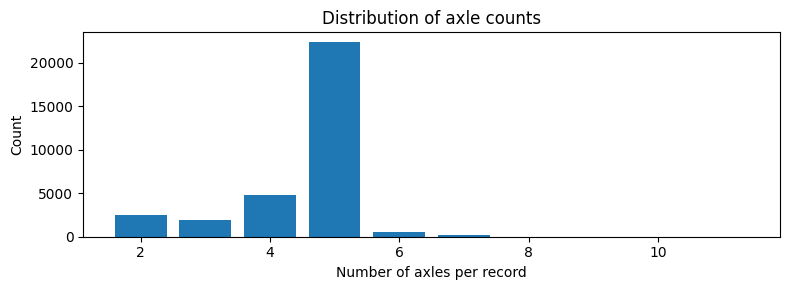

In [5]:
if PULSE_KEY:
    total_samples = 0
    total_pos     = 0
    axle_counts   = []

    for rec in raw:
        p = np.array(rec[PULSE_KEY], dtype=np.float32)
        # Count peaks: positions where pulse > 0.5 (works for binary & soft)
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(p, height=0.5, distance=5)
        axle_counts.append(len(peaks))
        total_pos     += float((p > 0.5).sum())
        total_samples += len(p)

    imbalance_ratio = total_samples / (total_pos + 1e-8)
    print(f'Positive samples : {total_pos/total_samples*100:.3f}%')
    print(f'Imbalance ratio  : {imbalance_ratio:.1f}x  (neg:pos = {imbalance_ratio-1:.1f}:1)')
    print(f'Axle count range : {min(axle_counts)} – {max(axle_counts)}')
    print(f'Mean axle count  : {np.mean(axle_counts):.2f}')

    axle_counter = Counter(axle_counts)
    plt.figure(figsize=(8, 3))
    plt.bar(axle_counter.keys(), axle_counter.values())
    plt.xlabel('Number of axles per record')
    plt.ylabel('Count')
    plt.title('Distribution of axle counts')
    plt.tight_layout()
    plt.show()

## 5. Visualise representative signal / pulse pairs

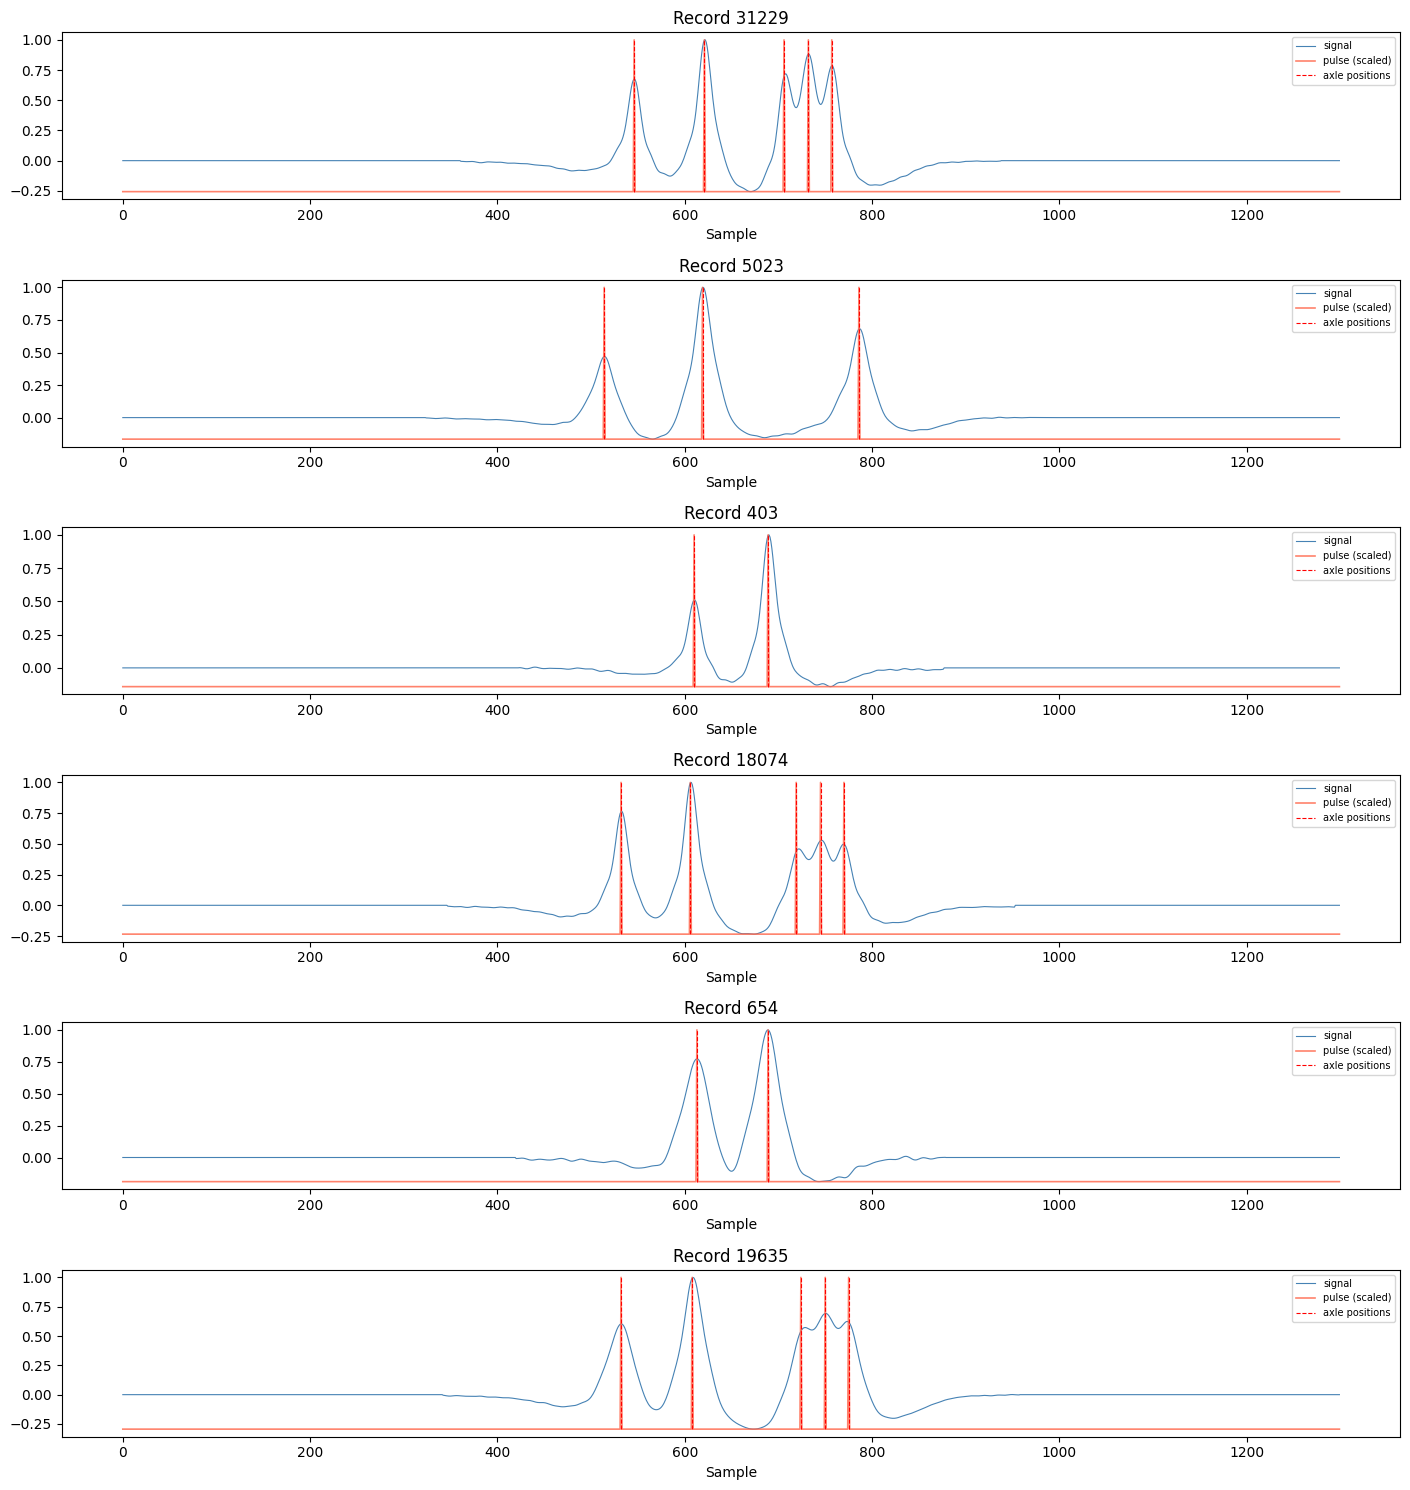

In [6]:
N_PLOT = 6
indices = np.random.choice(len(raw), N_PLOT, replace=False)

fig, axes = plt.subplots(N_PLOT, 1, figsize=(14, 2.5 * N_PLOT), sharex=False)
for ax, idx in zip(axes, indices):
    rec = raw[idx]
    sig = np.array(rec[SIGNAL_KEY], dtype=np.float32)
    ax.plot(sig, color='steelblue', linewidth=0.8, label='signal')
    if PULSE_KEY:
        pls = np.array(rec[PULSE_KEY], dtype=np.float32)
        # Scale pulses to signal range for visibility
        scale = (sig.max() - sig.min()) if sig.max() != sig.min() else 1.0
        pls_scaled = pls * scale + sig.min()
        ax.plot(pls_scaled, color='tomato', linewidth=1.2, alpha=0.8, label='pulse (scaled)')
        # Mark peak positions
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(pls, height=0.5, distance=5)
        ax.vlines(peaks, sig.min(), sig.max(), colors='red', linestyles='--',
                  linewidth=0.8, label='axle positions')

    ax.set_title(f'Record {idx}')
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xlabel('Sample')

plt.tight_layout()
plt.show()

## 6. Signal amplitude statistics

Global mean : 0.0323
Global std  : 0.1872
Global min  : -0.5170
Global max  : 1.0000


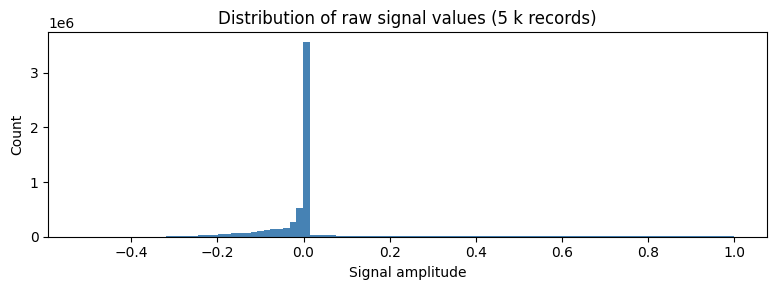

In [7]:
# Sample 5000 records for speed
sample_idx = np.random.choice(len(raw), min(5000, len(raw)), replace=False)
all_vals = np.concatenate([np.array(raw[i][SIGNAL_KEY], dtype=np.float32) for i in sample_idx])

print(f'Global mean : {all_vals.mean():.4f}')
print(f'Global std  : {all_vals.std():.4f}')
print(f'Global min  : {all_vals.min():.4f}')
print(f'Global max  : {all_vals.max():.4f}')

plt.figure(figsize=(8, 3))
plt.hist(all_vals, bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Signal amplitude')
plt.ylabel('Count')
plt.title('Distribution of raw signal values (5 k records)')
plt.tight_layout()
plt.show()

## 7. Pulse value distribution

Check whether pulses are binary (0/1) or soft/Gaussian-shaped — this determines whether we use `BCEWithLogitsLoss` or `MSELoss`.

Unique pulse values (first 20): [0.0, 1.0]
min=0.0000  max=1.0000
Pulses appear binary: True


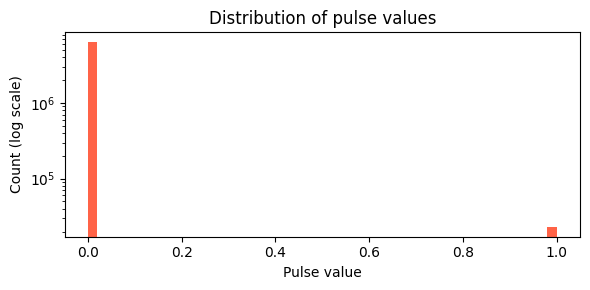

In [8]:
if PULSE_KEY:
    pulse_vals = np.concatenate([
        np.array(raw[i][PULSE_KEY], dtype=np.float32) for i in sample_idx
    ])
    unique_vals = np.unique(pulse_vals)
    print(f'Unique pulse values (first 20): {unique_vals[:20].tolist()}')
    print(f'min={pulse_vals.min():.4f}  max={pulse_vals.max():.4f}')
    is_binary = np.all(np.isin(pulse_vals, [0.0, 1.0]))
    print(f'Pulses appear binary: {is_binary}')
    if not is_binary:
        print('→ Consider MSELoss or treat values > 0.5 as positive')

    plt.figure(figsize=(6, 3))
    plt.hist(pulse_vals, bins=50, color='tomato', edgecolor='none', log=True)
    plt.xlabel('Pulse value')
    plt.ylabel('Count (log scale)')
    plt.title('Distribution of pulse values')
    plt.tight_layout()
    plt.show()